# WP1 — Ge(880) Von Hamos, passo per passo

Questo notebook usa le configurazioni JSON e le funzioni di `wp1_monoenergetic.py`, mostrando sorgente, footprint, traiettorie, scansione focale e piano del sample.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

candidates = [Path.cwd(), Path.cwd() / "3_Simulations", Path.cwd().parent]
SIMULATION_ROOT = next(
    path.resolve() for path in candidates
    if (path / "shadow4" / "wp1_monoenergetic.py").exists()
)
sys.path.insert(0, str(SIMULATION_ROOT / "shadow4"))

from wp1_monoenergetic import (
    beam_arrays, corrected_bragg_angle_rad, load_json, make_focus_scan,
    propagate_beam, sagittal_image_distance_m, spot_metrics, trace_crystal,
    usable_mask, von_hamos_symmetric_arm_m, weighted_sagittal_focus_m,
)

MAX_PLOT_RAYS = 5_000

## 1. Configurazione e geometria Von Hamos

In [2]:
source_config = load_json(SIMULATION_ROOT / "config" / "wp1_source.json")
geometry_config = load_json(SIMULATION_ROOT / "config" / "wp1_geometry.json")

energy_ev = 1_000.0 * source_config["energy_keV"]
crystal_config = geometry_config["crystal"]
theta_b = corrected_bragg_angle_rad(crystal_config, energy_ev)
radius_m = crystal_config["radius_m"]
source_distance_m = von_hamos_symmetric_arm_m(radius_m, theta_b)
sample_distance_m = sagittal_image_distance_m(
    source_distance_m, radius_m, theta_b
)

print(f"Energia: {energy_ev / 1e3:.3f} keV")
print(f"Angolo di Bragg: {np.degrees(theta_b):.4f} deg")
print(f"Sorgente → cristallo: {source_distance_m:.4f} m")
print(f"Cristallo → sample plane: {sample_distance_m:.4f} m")

Energia: 25.520 keV
Angolo di Bragg: 29.0644 deg
Sorgente → cristallo: 0.5146 m
Cristallo → sample plane: 0.5146 m


## 2. Sorgente e traccia sul cristallo

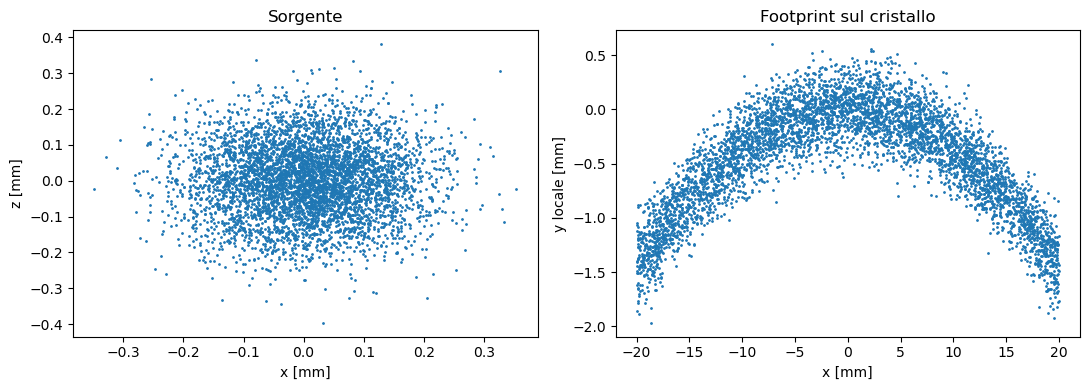

Raggi generati: 100000
Raggi validi dopo il cristallo: 65056


In [3]:
incident, footprint, post_crystal, coordinates = trace_crystal(
    source_config, geometry_config, source_distance_m, verbose_shadow4=False
)

incident_data = beam_arrays(incident)
footprint_data = beam_arrays(footprint)
post_data = beam_arrays(post_crystal)
good_fp = usable_mask(footprint_data)
good = usable_mask(post_data)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(1e3 * incident_data["x_m"][:MAX_PLOT_RAYS],
                1e3 * incident_data["z_m"][:MAX_PLOT_RAYS], s=1)
axes[0].set(title="Sorgente", xlabel="x [mm]", ylabel="z [mm]")
axes[1].scatter(1e3 * footprint_data["x_m"][good_fp][:MAX_PLOT_RAYS],
                1e3 * footprint_data["y_m"][good_fp][:MAX_PLOT_RAYS], s=1)
axes[1].set(title="Footprint sul cristallo",
            xlabel="x [mm]", ylabel="y locale [mm]")
plt.tight_layout()
plt.show()

print("Raggi generati:", incident.get_number_of_rays())
print("Raggi validi dopo il cristallo:", post_crystal.get_number_of_rays(nolost=1))

## 3. Traiettorie dopo il cristallo

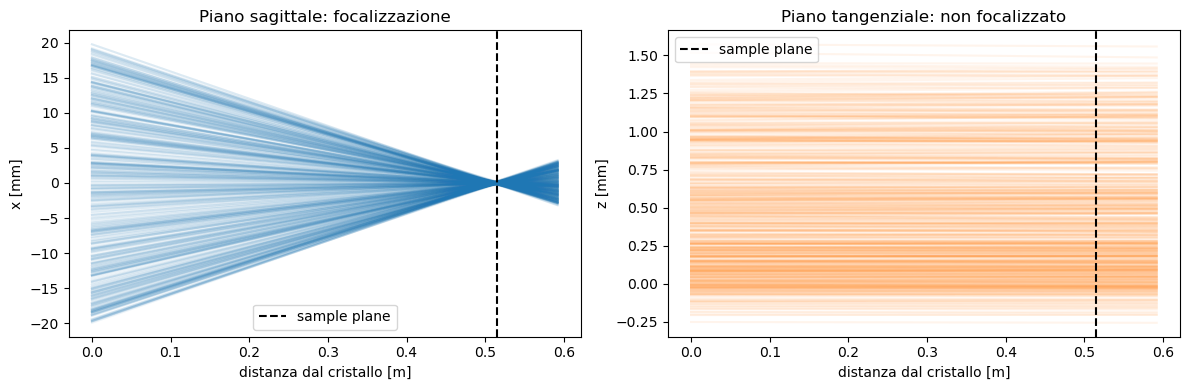

In [4]:
indices = np.flatnonzero(good)[:500]
longitudinal = np.linspace(0.0, 1.15 * sample_distance_m, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in indices:
    x = post_data["x_m"][i] + longitudinal * post_data["dx"][i] / post_data["dy"][i]
    z = post_data["z_m"][i] + longitudinal * post_data["dz"][i] / post_data["dy"][i]
    axes[0].plot(longitudinal, 1e3 * x, color="tab:blue", alpha=0.08)
    axes[1].plot(longitudinal, 1e3 * z, color="tab:orange", alpha=0.08)
for ax in axes:
    ax.axvline(sample_distance_m, color="black", ls="--", label="sample plane")
    ax.set_xlabel("distanza dal cristallo [m]")
    ax.legend()
axes[0].set(ylabel="x [mm]", title="Piano sagittale: focalizzazione")
axes[1].set(ylabel="z [mm]", title="Piano tangenziale: non focalizzato")
plt.tight_layout()
plt.show()

## 4. Profili trasversali lungo la propagazione

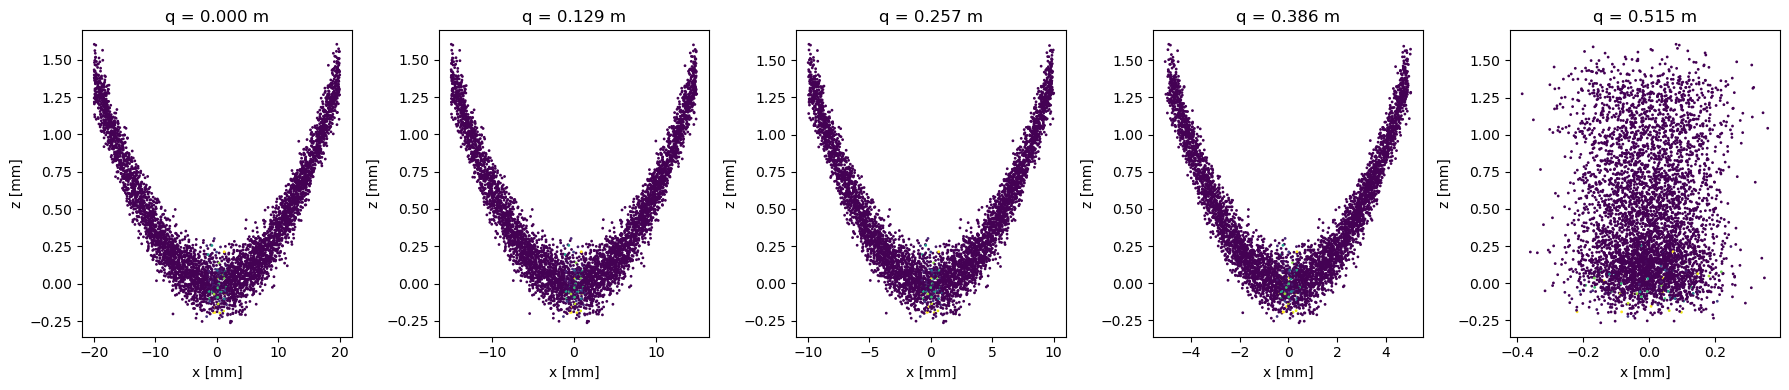

In [5]:
planes = np.linspace(0.0, sample_distance_m, 5)
fig, axes = plt.subplots(1, len(planes), figsize=(18, 4))
for ax, distance in zip(axes, planes):
    beam = propagate_beam(post_crystal, float(distance))
    data = beam_arrays(beam)
    mask = usable_mask(data)
    ax.scatter(1e3 * data["x_m"][mask][:MAX_PLOT_RAYS],
               1e3 * data["z_m"][mask][:MAX_PLOT_RAYS],
               c=data["weight"][mask][:MAX_PLOT_RAYS], s=1)
    ax.set(title=f"q = {distance:.3f} m", xlabel="x [mm]", ylabel="z [mm]")
plt.tight_layout()
plt.show()

## 5. Fuoco sagittale e piano del sample

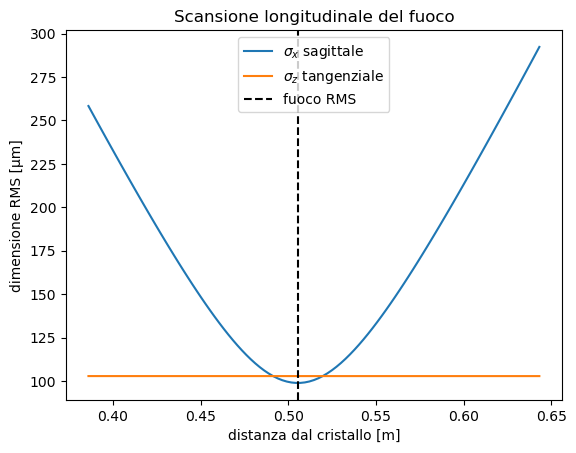

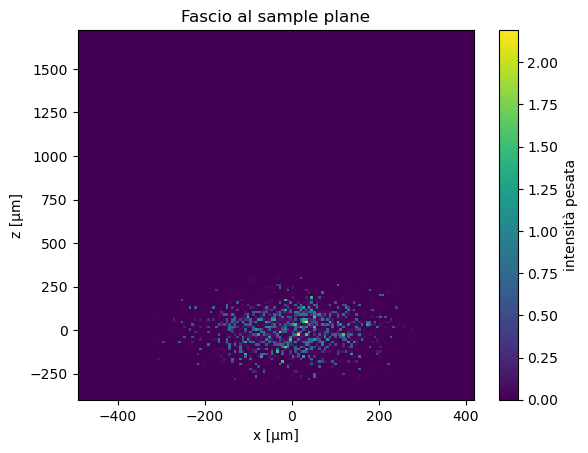

Fuoco RMS: 0.505493 m
Sigma x al sample: 100.555 µm
Sigma z al sample: 102.848 µm


In [6]:
focus_distance_m = weighted_sagittal_focus_m(post_data, good)
scan = make_focus_scan(
    post_data, good, sample_distance_m, geometry_config["focus_scan"]
)
q_scan = np.array([row["distance_m"] for row in scan])
sigma_x = 1e6 * np.array([row["sigma_x_m"] for row in scan])
sigma_z = 1e6 * np.array([row["sigma_z_m"] for row in scan])

plt.plot(q_scan, sigma_x, label=r"$\sigma_x$ sagittale")
plt.plot(q_scan, sigma_z, label=r"$\sigma_z$ tangenziale")
plt.axvline(focus_distance_m, color="black", ls="--", label="fuoco RMS")
plt.xlabel("distanza dal cristallo [m]")
plt.ylabel("dimensione RMS [µm]")
plt.title("Scansione longitudinale del fuoco")
plt.legend()
plt.show()

beam_at_sample_plane = propagate_beam(post_crystal, sample_distance_m)
sample_data = beam_arrays(beam_at_sample_plane)
sample_good = usable_mask(sample_data)
sample_metrics = spot_metrics(post_data, sample_distance_m, good)
plt.hist2d(1e6 * sample_data["x_m"][sample_good],
           1e6 * sample_data["z_m"][sample_good], bins=150,
           weights=sample_data["weight"][sample_good])
plt.xlabel("x [µm]")
plt.ylabel("z [µm]")
plt.title("Fascio al sample plane")
plt.colorbar(label="intensità pesata")
plt.show()

print(f"Fuoco RMS: {focus_distance_m:.6f} m")
print(f"Sigma x al sample: {1e6 * sample_metrics['sigma_x_m']:.3f} µm")
print(f"Sigma z al sample: {1e6 * sample_metrics['sigma_z_m']:.3f} µm")